# Ayudantía N°4

<h2 style = "color: chocolate">Investigación Aréas Verdes: Vitacura</h2>

### Diego Bernal

--- 

Premisa queremos ver el efecto en la temperatura de las aréas verdes en la comuna de Vitacura.




In [2]:
#%%capture

In [3]:
import geopandas as gpd

c:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
Vitacura = gpd.read_file("./data/COMUNA_C17.shp")
AOI = Vitacura.query('NOM_COMUNA == "VITACURA"')

In [5]:
AOI.to_file("./data/Vitacura.shp")

<Axes: >

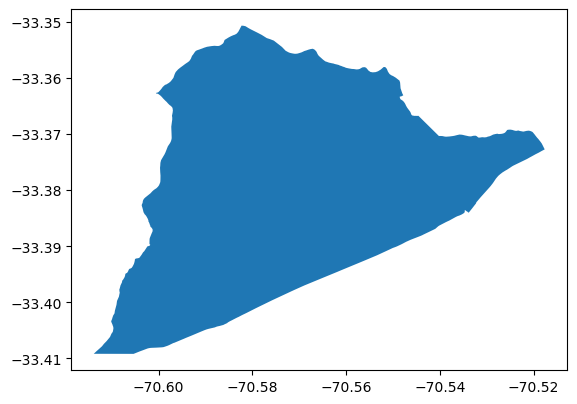

In [6]:
AOI.plot()

In [7]:
import ipywidgets
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import pandas as pd
import numpy as np
import fiona
from fiona.drvsupport import supported_drivers
import googlemaps
from datetime import datetime
import ee
import geemap
import rasterio
from rasterio.plot import show
from rasterio.plot import show_hist
from matplotlib import pyplot
from shapely.geometry import shape
import rasterio.features
from sklearn.preprocessing import StandardScaler
import os
import elevation
import rioxarray as riox
from rasterio.plot import show
from rasterio import features
from rasterio.enums import MergeAlg
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt
from shapely.geometry import mapping

In [8]:
# Iniciar flujo de autentificación, En caso de que no estes logeado por favor elimina la grilla y inicia tu cuenta en
# earth engine
#ee.Authenticate()
 
# Inicializar la librería.
ee.Initialize()

In [9]:
unified_polygon = AOI.unary_union

In [10]:
Vita_poly = unified_polygon.convex_hull

In [11]:
Vita_cen = Vita_poly.centroid

In [12]:
xx, yy = Vita_poly.exterior.coords.xy

# Crear una lista de coordenadas
coordinates = [[x, y] for x, y in zip(xx, yy)]

In [13]:
Vitacura = ee.Geometry.Polygon(coordinates)
Vitacura

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -70.60535275999996,
              -33.40917958799997
            ],
            [
              -70.60535429899994,
              -33.40917958599994
            ],
            [
              -70.61211695999998,
              -33.40916873499998
            ],
            [
              -70.61296871199994,
              -33.40916735999997
            ],
            [
              -70.61384607099995,
              -33.40916594299995
            ],
            [
              -70.61384699199994,
              -33.40916593299994
            ],
            [
              -70.60057697999997,
              -33.362699119999945
            ],
            [
              -70.59585357499998,
              -33.358489695999936
            ],
            [
              -70.59223973899998,
              -33.35534356299996
            ],
            [
              -70.59202837399994,
              -33.35517041399993
            ],
            [
              -70.58232999999996,
              -33.35068999999993
            ],
            [
              -70.58223669599994,
              -33.350695230999975
            ],
            [
              -70.58190283599998,
              -33.35071394899995
            ],
            [
              -70.58145610099996,
              -33.350800806999985
            ],
            [
              -70.55166181299995,
              -33.35806273099996
            ],
            [
              -70.52051105099997,
              -33.369518194999955
            ],
            [
              -70.52024742299994,
              -33.36963025799997
            ],
            [
              -70.52023797899994,
              -33.369634272999974
            ],
            [
              -70.52021730299998,
              -33.369651174999944
            ],
            [
              -70.52011478199995,
              -33.36973498599997
            ],
            [
              -70.51895737499996,
              -33.37091706199993
            ],
            [
              -70.51890391299997,
              -33.37097182799994
            ],
            [
              -70.51858817399994,
              -33.371300359999964
            ],
            [
              -70.51839850099998,
              -33.37151912699994
            ],
            [
              -70.51826482099995,
              -33.371674077999955
            ],
            [
              -70.51819550599998,
              -33.37178314899995
            ],
            [
              -70.51813288899996,
              -33.37188639699997
            ],
            [
              -70.51807881399998,
              -33.37197556099994
            ],
            [
              -70.51797509199997,
              -33.372146587999964
            ],
            [
              -70.51771495699995,
              -33.37258266099997
            ],
            [
              -70.51762512499994,
              -33.37274602499997
            ],
            [
              -70.51762389099997,
              -33.37274827099998
            ],
            [
              -70.53384746699999,
              -33.38402850999995
            ],
            [
              -70.54378312899996,
              -33.38804266099993
            ],
            [
              -70.58619394499993,
              -33.40402625499996
            ],
            [
              -70.59812942699995,
              -33.40774402399995
            ],
            [
              -70.59861729999994,
              -33.40788207199995
            ],
            [
              -70.59869553099998,
              -33.407904207999934
            ],
            [
              -70.59884725499995,
              -33.40794713899993
            ],
            [
              -70.59900723999993,
              -33.4

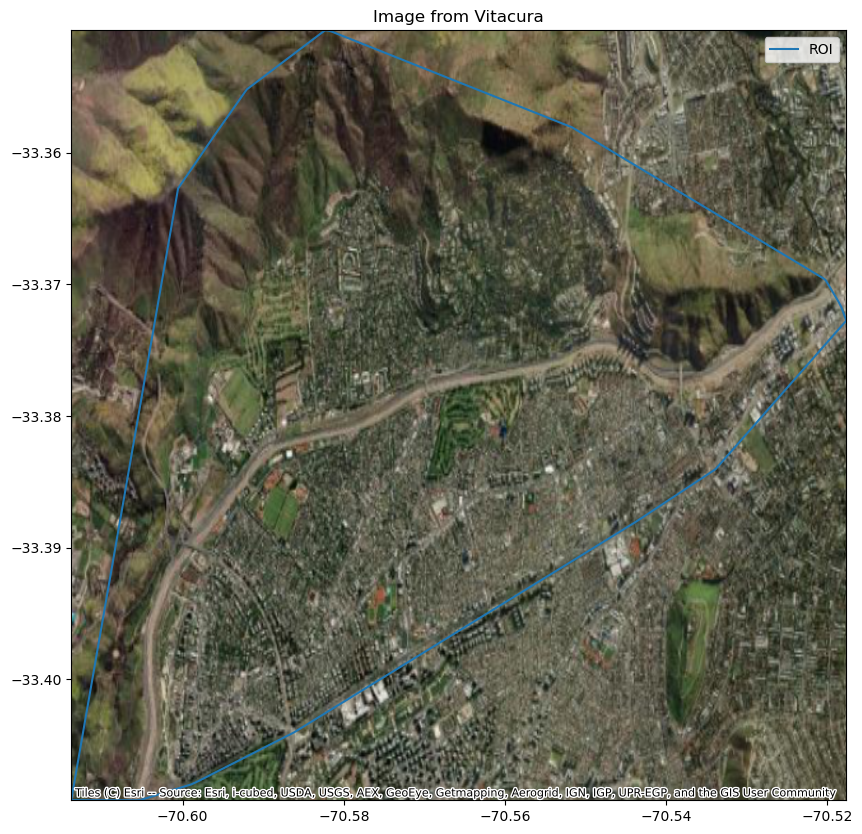

In [14]:
import contextily as ctx
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)

x=np.array([p[0] for p in coordinates])
y=np.array([p[1] for p in coordinates])

ax.plot(x,y,label = 'ROI')

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

ax.legend()
ax.set_title('Image from Vitacura')
ctx.add_basemap(ax,crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery)

In [15]:
def calculate_cloud_percentage(image):
    cloud_percentage = image.select(['QA60']).bitwiseAnd(1 << 10).eq(0) \
        .reduceRegion(reducer=ee.Reducer.mean(), geometry=Vitacura, scale=10, maxPixels=1e9) \
        .get('QA60')
    return image.set('cloud_percentage', cloud_percentage)

In [16]:
colecci_20 = ee.ImageCollection('COPERNICUS/S2_SR').filterBounds(Vitacura).filterDate('2024-01-01', '2024-03-30')
colecci_20

c:\Users\Diego\anaconda3\Lib\site-packages\ee\deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


KeyboardInterrupt: 

In [ ]:
colecci_20_with_cloud_percentage = colecci_20.map(calculate_cloud_percentage)
colecci_lan_filtered_20 = colecci_20_with_cloud_percentage.filterMetadata('cloud_percentage', 'less_than', 1.2)

In [ ]:
colecci_lan_filtered_20

c:\Users\Diego\anaconda3\Lib\site-packages\eerepr\repr.py:57: UserWarning: Getting info failed with: 'Error in map(ID=20240217T143749_20240217T144515_T19HCD):
Image.select: Band pattern 'QA60' did not match any bands. Available bands: [B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12, AOT, WVP, SCL, TCI_R, TCI_G, TCI_B, MSK_CLDPRB, MSK_SNWPRB, MSK_CLASSI_OPAQUE, MSK_CLASSI_CIRRUS, MSK_CLASSI_SNOW_ICE]'. Falling back to string repr.
  warn(f"Getting info failed with: '{e}'. Falling back to string repr.")


In [ ]:
colecci_lan_filtered_20.sort('CLOUD_COVER_LAND')

In [ ]:
best_image_2020 = colecci_20.sort('CLOUD_COVER_LAND')
best_image_2020 = best_image_2020.toList(best_image_2020.size()) 

In [ ]:
best_image_2020.get(2)

In [ ]:
#geemap.ee_export_image(ee.Image(best_image_2020.get(3)), filename='./imgs/Sentinel_2_2024.tif', crs="EPSG:4326", scale=10,region=Vitacura)

<h2>Start with the masking of the images</h2>

In [ ]:
src=rasterio.open('./imgs/Sentinel_2_2020.tif') 
bandas = [2,3,4]
image = src.read()
image_ = image[bandas]

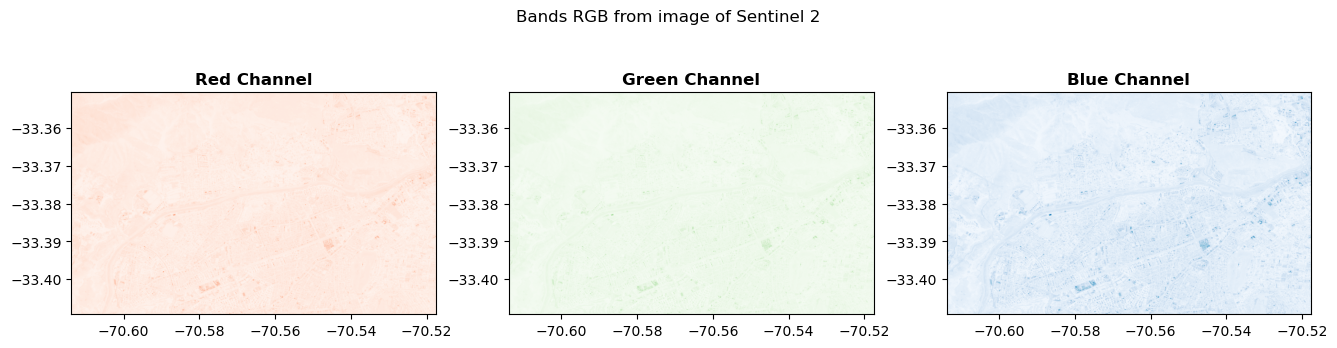

In [ ]:
fig,axes=plt.subplots(figsize=(16,4),nrows=1,ncols=3)
show((src, 4), cmap='Reds', title='Red Channel',ax=axes[0])
show((src, 3), cmap='Greens', title='Green Channel',ax=axes[1])
show((src, 2), cmap='Blues', title='Blue Channel',ax=axes[2]);
fig.suptitle('Bands RGB from image of Sentinel 2 ')

# Muestra la figura
plt.show()

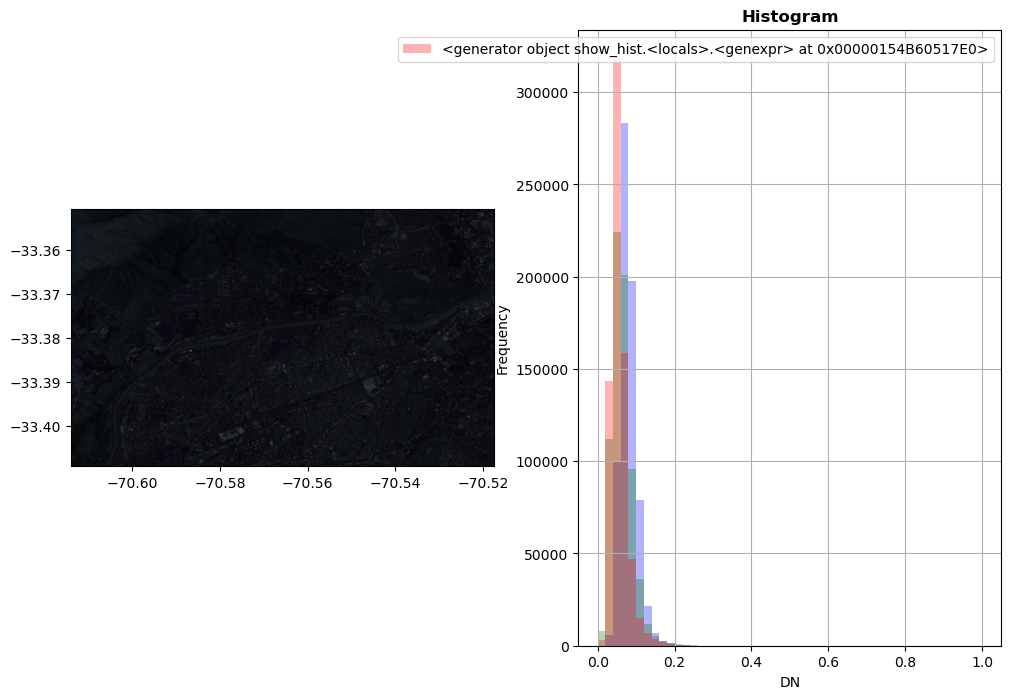

In [ ]:
fig,axes=plt.subplots(figsize=(12,8),nrows=1,ncols=2)

image_norm = (image_ - image_.min()) / (image_.max() - image_.min())
show(image_norm,transform=src.transform,ax=axes[0]);

show_hist(image_norm, bins=50, lw=0.0, stacked=False, alpha=0.3,histtype='stepfilled', title="Histogram", ax=axes[1]);

In [ ]:
def normalize(band):
    band_min, band_max = (band.min(), band.max())
    return ((band-band_min)/((band_max - band_min)))

def brighten(band):
    alpha=0.06
    beta=0
    return np.clip(alpha*band+beta, 0,255)

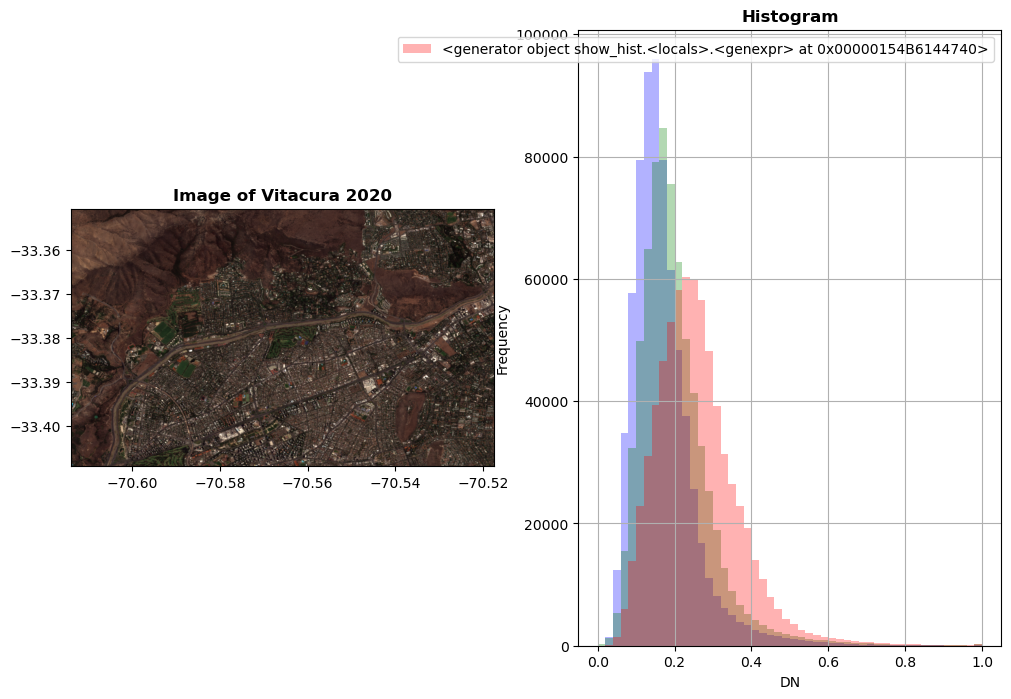

In [ ]:
red = src.read(4)
green = src.read(3)
blue = src.read(2)

#brillo
red_b=brighten(red)
blue_b=brighten(blue)
green_b=brighten(green)


#normalizar
red_bn = normalize(red_b)
green_bn = normalize(green_b)
blue_bn = normalize(blue_b)

#formar el stack RGB
rgb_composite_bn=np.array([red_bn,green_bn,blue_bn])

#plot con coordenadas
fig,axes=plt.subplots(figsize=(12,8),nrows=1,ncols=2)



show(rgb_composite_bn,transform=src.transform,ax=axes[0],title='Image of Vitacura 2020');

show_hist(rgb_composite_bn, bins=50, lw=0.0, stacked=False, alpha=0.3,histtype='stepfilled', title="Histogram", ax=axes[1]);


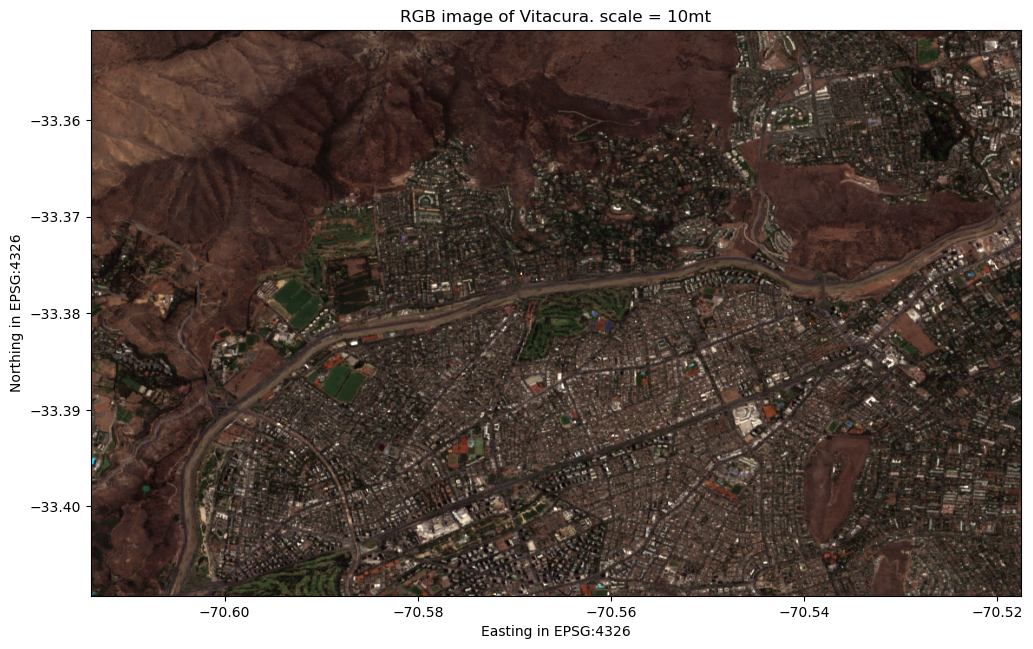

In [ ]:
from rasterio.plot import show
fig=plt.figure(figsize=(12,12))
ax=fig.add_subplot(111)
show(rgb_composite_bn,transform=src.transform,ax=ax);



ax.set_title('RGB image of Vitacura. scale = 10mt')
ax.set_xlabel('Easting in EPSG:4326')
ax.set_ylabel('Northing in EPSG:4326')

plt.show()

In [ ]:
geo = [mapping(Vita_poly)] #Convierte mejor la imagen

In [ ]:
with rasterio.open("./imgs/Sentinel_2_2024.tif") as src:
    # Aplicar el clip utilizando la geometría del convex_hull
    clipped_image, clipped_transform = mask(src, geo, crop=True)
    left, top = clipped_transform * (0, 0)
    right, bottom = clipped_transform * (clipped_image.shape[2], clipped_image.shape[1])

# Print the new bounds
print(f"Clipped Image Bounds: Left: {left}, Right: {right}, Bottom: {bottom}, Top: {top}")

Clipped Image Bounds: Left: -70.61386953878322, Right: -70.5175701403256, Bottom: -33.40924373168912, Top: -33.35067357516453


# Classification of NDVI bodies in Vitacura each year

In [ ]:
red_band = clipped_image[3]       # Red (B4)
green_band = clipped_image[2]     # Green (B3)
blue_band = clipped_image[1]      # Blue (B2)
nir_band = clipped_image[7]       # NIR (B8)
swir_band = clipped_image[11]     # SWIR (B12) or clipped_image[10] for SWIR at 1.6 μm (B11)
nir_swir_band = clipped_image[10]


ndvi = (nir_band - red_band) / (nir_band + red_band)

# Classification based on NDVI threshold
classification = np.full(ndvi.shape, 0)

# Then classify vegetation where NDVI is high
classification = np.where(ndvi > 0.5, 1, classification)  # Vegetation = 1


#with rasterio.open('./imgs/Vegetation_2024.tif', 'w', driver='GTiff', height= clipped_image.shape[1], width= clipped_image.shape[2], count=1, dtype='uint8', crs=src.crs, transform=clipped_transform) as dst:
    #dst.write(classification, 1)
#

C:\Users\Diego\AppData\Local\Temp\ipykernel_32308\1264827814.py:9: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir_band - red_band) / (nir_band + red_band)


In [ ]:
with rasterio.open("./imgs/Vegetation_2020.tif") as src_:
    # Aplicar el clip utilizando la geometría del convex_hull
    clipped_image_, clipped_transform_ = mask(src_, geo, crop=True)

<Axes: title={'center': 'Vegetation bodies in Vitacura'}>

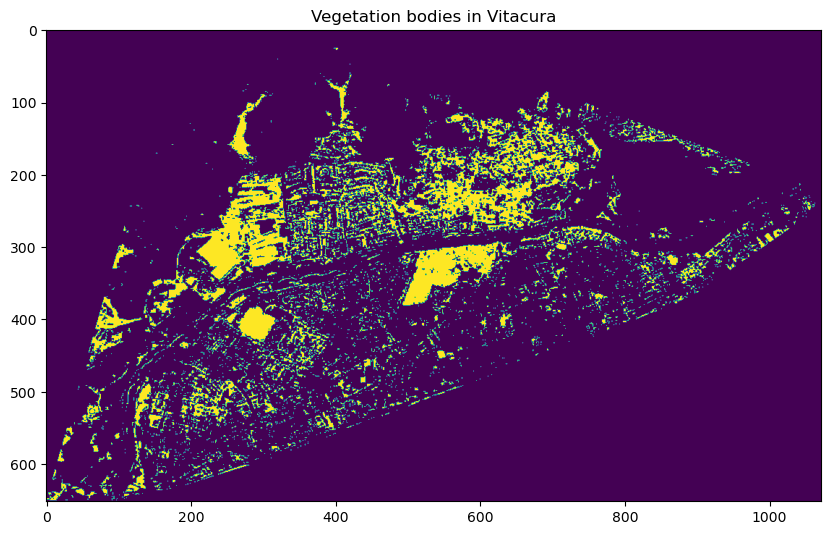

In [ ]:
fig, ax = plt.subplots(1, figsize = (10, 10))
ax.set_title('Vegetation bodies in Vitacura')
show(clipped_image_, ax = ax)
plt.gca()

In [37]:
poligonos = gpd.read_file("./data/grilla_poligonos.shp")

Extraemos que poligonos tienen vegetación

In [41]:
vegetation=rasterio.open('./imgs/Vegetation_2020.tif')

In [38]:
coord_list = [(x,y) for x,y in zip(poligonos['geometry'].centroid.x ,poligonos['geometry'].centroid.y)]
print(len(coord_list))

17407


C:\Users\Diego\AppData\Local\Temp\ipykernel_12640\458069518.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coord_list = [(x,y) for x,y in zip(poligonos['geometry'].centroid.x ,poligonos['geometry'].centroid.y)]


In [42]:
dat=[x[0] for x in vegetation.sample(coord_list)]
poligonos['vegetacion']=dat

In [50]:
poligonos.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 17407 entries, 0 to 17406
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         17407 non-null  int64   
 1   geometry    17407 non-null  geometry
 2   vegetacion  17407 non-null  uint8   
 3   lst         17407 non-null  float64 
dtypes: float64(1), geometry(1), int64(1), uint8(1)
memory usage: 425.1 KB


In [82]:
gdf_veg = poligonos[poligonos['vegetacion'] == 1].copy().reset_index(drop=True)

In [83]:
import networkx as nx

In [84]:
sindex = gdf_veg.sindex
G = nx.Graph()

In [85]:
for idx, geom in gdf_veg.geometry.items():
    posibles_vecinos = list(sindex.intersection(geom.bounds))
    
    for vecino_idx in posibles_vecinos:
        if idx == vecino_idx:
            continue
        if geom.touches(gdf_veg.geometry[vecino_idx]) or geom.intersects(gdf_veg.geometry[vecino_idx]):
            G.add_edge(idx, vecino_idx)

In [86]:
componentes = list(nx.connected_components(G))

In [87]:
todos_indices = set(range(len(gdf_veg)))
indices_sueltos = todos_indices - set().union(*componentes)
componentes.extend([{idx} for idx in indices_sueltos])

In [88]:
geoms_agrupadas = []
for grupo in componentes:
    if len(grupo) >30:
        unidos = gdf_veg.loc[list(grupo)].unary_union
        geoms_agrupadas.append(unidos)


In [89]:
gdf_veg = gpd.GeoDataFrame(geometry=geoms_agrupadas, crs=poligonos.crs)

In [92]:
gdf_veg.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  7 non-null      geometry
dtypes: geometry(1)
memory usage: 188.0 bytes


<Axes: >

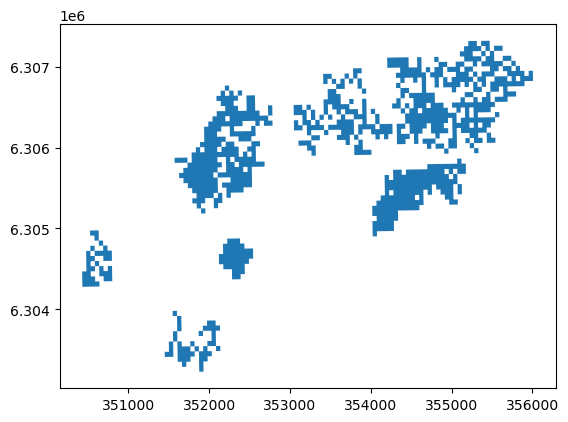

In [119]:
gdf_veg.plot()

In [151]:
gdf_buffer = gpd.read_file('./data/buffer_distance_vegetation300.shp')

In [ ]:
#gdf_veg.to_file('./data/vegetation_polygons_unified/vegetation_parks.shp')

In [124]:
import contextily as ctx
from shapely.ops import nearest_points

In [127]:
def calcular_distancia(row, target_gdf):
    # Encuentra el punto más cercano en `gdf_vegetacion` al polígono en `row`
    nearest_geom = target_gdf.geometry.unary_union  # Unión geométrica de todos los polígonos de vegetación
    nearest_point = nearest_points(row.geometry, nearest_geom)[1]  # Encuentra el punto más cercano en `nearest_geom`
    return row.geometry.distance(nearest_point)

In [202]:
gdf_lst_points = gpd.read_file('./data/lst_points/lst_distance_2020.shp')

In [196]:
gdf_lst_points = gdf_lst_points.to_crs('32719')

In [197]:
gdf_lst_points = gpd.sjoin(gdf_lst_points,gdf_buffer,predicate='within', how='inner')

In [198]:
gdf_lst_points['distancia_vegetacion'] = gdf_lst_points.apply(calcular_distancia, target_gdf=gdf_veg, axis=1)

In [203]:
gdf_lst_points = gdf_lst_points.drop(columns=['index_right'], errors='ignore')

In [204]:
gdf_lst_points_ = gpd.sjoin(gdf_lst_points, gdf_veg, predicate='within', how='left')
gdf_lst_points_out = gdf_lst_points_[gdf_lst_points_['index_right'].isna()].copy()

In [205]:
gdf_lst_points_out

,X2020__,index_righ,distance,distancia_,geometry,index_right
0,31.137485,6,300,299.155477,POINT (355084.976 6307592.634),NaN
1,31.703167,6,300,290.228327,POINT (355110.052 6307593.009),NaN
2,32.359427,6,300,283.246871,POINT (355135.128 6307593.383),NaN
3,32.890929,6,300,278.357547,POINT (355160.203 6307593.758),NaN
4,33.237858,6,300,275.671695,POINT (355185.279 6307594.133),NaN
...,...,...,...,...,...,...
18648,34.456382,0,300,285.387362,POINT (351920.590 6302941.800),NaN
18649,34.628992,0,300,285.608498,POINT (351945.654 6302942.183),NaN
18650,34.628992,0,300,287.687187,POINT (351970.718 6302942.567),NaN
18651,34.948577,0,300,291.911551,POINT (351995.782 6302942.950),NaN


In [206]:
gdf_lst_points_out.to_file('./data/lst_points/lst_distance_2020.shp')

C:\Users\Diego\AppData\Local\Temp\ipykernel_12640\3459567269.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_lst_points_out.to_file('./data/lst_points/lst_distance_2020.shp')


Tranform to CRS 32719 and estimate buffers from 100 to 5000 mts and make and cardinal of 300 and then estimate figures to extrac points of interest for the effects


In [115]:
distances =list(range(100,301,20))

In [116]:
gdf_veg=gdf_veg.to_crs('32719')

In [117]:
for d in distances:
    gdf_buffer = gdf_veg.copy()
    gdf_buffer['distance'] = d
    gdf_buffer['geometry'] = gdf_buffer.buffer(d)
    gdf_buffer.to_file(f'./data/buffer_distance_vegetation{d}.shp')

<h2>LST in Vitacura</h2>

In [ ]:
años = [2020, 2021, 2022, 2023,2024]
coleccion = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")

imagenes_por_año = {}

for año in años:
    verano = coleccion.filterBounds(Vitacura) \
                      .filter(ee.Filter.calendarRange(año, año, 'year')) \
                      .filter(ee.Filter.calendarRange(1, 3, 'month')) \
                      .filter(ee.Filter.lt('CLOUD_COVER', 20))

    def convertir_temp(img):
        temp = img.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15)
        return temp.clip(Vitacura).set('system:time_start', img.get('system:time_start'))

    temperatura = verano.map(convertir_temp)

    imagen_median = temperatura.median()

    imagenes_por_año[str(año)] = imagen_median


In [ ]:
lista_emb = ['2020_lst_Vita.tif', '2021_lst_Vita.tif', '2022_lst_Vita.tif', '2023_lst_Vita.tif', '2024_lst_Vita.tif']
lista_img = [imagenes_por_año[str(año)] for año in años]
escala = 30
region = Vitacura

for imagen, nombre_archivo in zip(lista_img, lista_emb):
    geemap.ee_export_image(imagen, filename=f'./imgs/{nombre_archivo}', scale=escala, region=region)

In [19]:
lst=rasterio.open('./imgs/2020_lst_Vita.tif')

In [20]:
datos_modis = lst.read(1)

In [32]:
np.max(datos_modis)

51.105557480000016

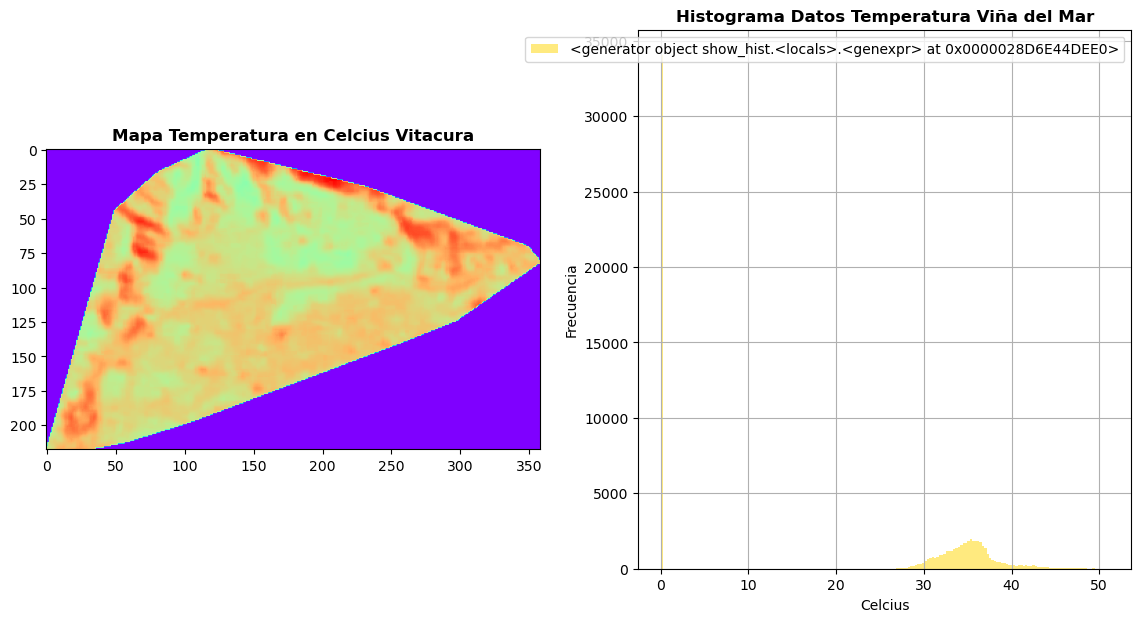

In [34]:
fig, (mapV,HistV ) = pyplot.subplots(1, 2, figsize=(14,7))
show(datos_modis, ax=mapV,cmap='rainbow',title = 'Mapa Temperatura en Celcius Vitacura', vmin = 0, vmax = 51)
show_hist(datos_modis, title="Histograma Datos Temperatura Viña del Mar",alpha=0.5,histtype='stepfilled',ax=HistV,bins=187)
HistV.set_xlabel('Celcius')
HistV.set_ylabel('Frecuencia')
pyplot.show()

In [44]:
dat=[x[0] for x in lst.sample(coord_list)]
poligonos['lst']=dat

In [207]:
poligonos.to_file('./data/poligonos_grilla_lst_vegetacion.shp')

In [216]:
gdf_veg = gdf_veg.to_crs('4326')
gdf_lst_points_out = gdf_lst_points_out.to_crs('4326')
gdf_lst_points_out = gdf_lst_points_out.sample(n=200, random_state=42) 

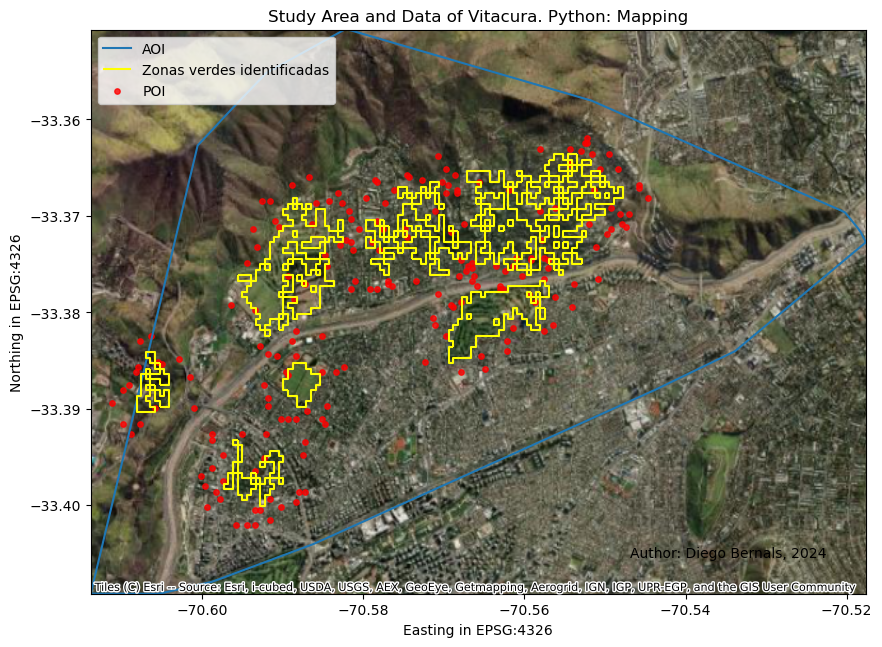

In [221]:
import contextily as ctx
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)


x= np.array([p[0] for p in coordinates])
y= np.array([p[1] for p in coordinates])


ax.plot(x,y, label = 'AOI')


ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

ax.legend()
ctx.add_basemap(ax,crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery)

gdf_veg.boundary.plot(ax=ax,color='yellow',label='Zonas verdes identificadas')
gdf_lst_points_out[:200].plot(ax=ax, color='red', marker='o', markersize=15, label='POI', alpha=0.8)
ax.set_title('Study Area and Data of Vitacura. Python: Mapping')
ax.set_xlabel('Easting in EPSG:4326')
ax.set_ylabel('Northing in EPSG:4326')

ax.legend(loc='upper left')

author_text = "Author: Diego Bernals, 2024"
ax.text(0.95, 0.06, author_text, transform=ax.transAxes, fontsize=10, color='black',
        ha='right', va='bottom', alpha=1)
plt.show()